In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

E0000 00:00:1748884797.236527   13593 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748884797.244897   13593 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748884797.288485   13593 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748884797.288559   13593 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748884797.288562   13593 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748884797.288564   13593 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
#dev = tf.config.list_physical_devices()
#print('Available Devices : ', dev)
#tf.config.set_visible_devices(dev[0], 'CPU')
#tf.config.set_visible_devices(dev[1], 'GPU')

# Chapter 4: Getting Started with neural Networks: Classification and Regression

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

The examples from this chapter show some basic end-to-end machine learning workflows.  We introduce data preprocessing,
basic model architecture principles, and model evaluation.

There are examples of classification and regression problems.  Make sure you understand the fundamental difference.
A classification problem is when we try to predict a label.  For example, the simpliest classification is binary
classification.  We will predict movie reviews where the class label of the review was either positive or negative,
this is a binary classification problem.  Classification can be more complex.  We have already seen
examples of multiclass classification with the MNIST training set.  In that case, we are trying to predict which of
10 digits each image belongs to.  This is an example of multiclass classification.

A regression problem then is one where we are trying to predict a continuous value.  A good example is predicting house
prices from house features, which we have also seen examples of so far in this class.



# 4.1 Classifying movie reviews: A binary classification example

Two-class classification, or binary classification, is one of the most common kinds of machine
learning problem.

## 4.1.1 The IMDB dataset

Another example of a test/example dataset.  The IMDB dataset has 50,000 reviews from the
Internet Movie DataBase.  They are evenly split into 25,000 reviews for training and
25,000 reviews for testing.  Also each is evenly split with 50% negative and 50% positive
reviews.

Keras has the IMDB dataset available in its datasets module.  It has already been preprocessed,
the reviews which are sequences of words have been turned into sequences of integers, where each
integer stands for a specific word in the dictionary.  We would normally have to do a preprocessing
step like this ourselves if working on a new text based dataset.  But ML models can't use text as
input, we have to convert text into some numeric representation to be used as input to a ML model
(often referred to as a vector space).

The following code will load the dataset.  The first time you run it it will need to download
a lot of data (16MB compressed, 80MB uncompressed), but after downloading it will be available on your local system if you
rerun.

In [3]:
from tensorflow.keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

The argument `num_words=10000` means we keep only the top 10,000 most frequently occurring words in the
training data.

The variables `train_data` and `test_data` are lists of reviews.  Each review is a list of word indices.

`train_labels` and `test_labels` are our binary labels, 0 for *negative* reviews and 1 for *positive* reviews.

In [4]:
print(train_data.shape)
print(train_data.dtype)
print(train_data[0])
print(type(train_data[0]))
print(len(train_data[0]))

(25000,)
object
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
<class 'list'>
218


In case it is not clear, there are actually 25,000 samples in the `train_data` tensor.  It looks like a 1-D tensor, which might be confusing.  But each sample is actually
a regular Python `list`.  The lists are of variable size.  For example, the review for sample 0 has 218 words in the list of word indexes for that review.

Because we restriced to 10,000 most frequent words, no word index should exceed 10,000 (here for each sample we find the maximum word index, and check what the maximum of the
maximum for each sample is).

In [5]:
max([max(sample) for sample in train_data])

9999

An example of decoding a review back to English words.  The `imdb` module from `keras` has a `word_index` dictionary.  
For example, if you want to know the index associated with the word "nuclear", we can look it up in the dictionary
(it was given index number 3475).

In [6]:
# word_index is a dictionary mapping words to an integer index
word_index = imdb.get_word_index()

word_index["nuclear"]

3475

In order to decode a review, we need to perform the opposite of the current dictionary, we need to be able to look up the
index number and get the word associated with it.  So reverse the mapping of the dictionary.

In [7]:
# reverse the mapping, mapping integer indices to the words using the word_index dict
reverse_word_index = dict(
    [(value, key) for (key, value) in word_index.items()]
)

# for example, now if we have index 3475 we can find out which word that is
reverse_word_index[3475]

'nuclear'

With our reverse word index, we can decode any sample movie review we want from train or test data like this:

In [8]:
# decode review.  Note that indices are offset by 3 because 0, 1 and 2 are reserved indices
# for "padding", "start of sequence" and "unknown"
review_no = 12345
decoded_review = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[review_no]]
)

print(decoded_review)

? in the sea of crap that hollywood and others continue to put out this is one of those ? in the rough a small simple movie that is very entertaining and leaves you with the feeling that you didn't just waste an hour and a half of your life br br ashley judd is really quite amazing in this movie i had never really been a fan or had noticed her before but going back and seeing this early performance of hers convinced me she's extremely talented br br watching this film was an assignment in a college course for me so i was skeptical i would even care i thought oh boy some dumb ? flick or feminist male bashing indie crap i was pleasantly surprised without ? the many relevant themes i'll just say if you haven't seen it do yourself a favor and check it out sometimes the down to earth slice of life movies are the best and this is a great one


And if you are paying attention here, we actually need to subtract 3 from a word index because the first 3 indexes are reserved for special
characters.  So the actual word 3475 if we saw it in a review is:

In [9]:
reverse_word_index[3475 - 3]

'typically'

## 4.1.2 Preparing the data

As you may have noticed, the reviews are simple (regular python) lists of integers.  The reviews are of different lengths, e.g.

In [10]:
print(len(train_data[0]))
print(len(train_data[1]))

218
189


We need to process these lists into some other format to be suitable as input for a ML algorithm, like a neural network.  You can't
directly feed in uneven lists of integers.  We have to turn the lists into tensors.  Two basic methods are used to do this:

1. Pad lists so they all have the same length. e.g. turn into tensor of shape `(samples, max_length)`.
2. **Multi-hot encode** your lists to turn them into vectors of 0s and 1s.  Since we restricted to 10,000 words this would mean we
   have 10,000 features in the tensor, where a 1 indicates that word was present (maybe multiple times) in the review, and a 0 
   indicates the word was not present.  This may result in relatively sparse representations.
   
In our following example, we use approach 2.

**NOTE**: There are tradeoffs here that will be discussed later.  For example, for the multi-hot encoding we are using, we
no longer have any sense of the order of the words, nor do we know if a word is used 2 or more times in the review, we simply
only know which words were present and which were absent.

Encoding the integer sequences via multi-hot encoding by hand.


In [11]:
def vectorize_samples(samples, dimension=10000):
    """Vectorize word index sequences into a multi-hot encoding.
    The sequences is an array of regular python lists.  We hot encode
    each word we find in the list into a vector of the indicated number
    of feature dimensions, one vector for each of the word sequences /
    reviews.

    Arguments
    ---------
    samples - A numpy array of shape (samples,).  We expect each item in the array
      to be an object type, which will be a Python list or equivalent sequence of
      word indexes
    dimension - Default to 10000 for this problem, but if we load the imdb with
      a different max words we would need to adjust.  Though we could infer this
      dynamically but examing the samples as we did before if we wanted to.

    Returns
    -------
    multi_hot_encoded_samples - A tensor of shape (samples, dimension) where each sample
       has multi-hot encoded the original sequential word list review.
    """
    # initialize a tensor/array of the correct shape, initialized to all 0's
    multi_hot_encoded_samples = np.zeros((len(samples), dimension))
    
    # set specific index to 1 for each word index encountered in the review
    for sample_num, sample in enumerate(samples):
        for word_index in sample:
            # we could increment the count here if wanted a multi-hot encoding
            # counting the number of times the word occurs
            multi_hot_encoded_samples[sample_num, word_index] = 1
            
    return multi_hot_encoded_samples

# vectorize the training and test data
x_train = vectorize_samples(train_data)
x_test = vectorize_samples(test_data)

Here is what the sample inputs look like now.

In [12]:
print(x_train.shape)
print(x_train[0])

(25000, 10000)
[0. 1. 1. ... 0. 0. 0.]


We also need to vectorize the labels to get them into format needed by Keras/TensorFlow.

In [13]:
print(train_labels.dtype)
print(train_labels.shape)

y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

print(y_train.dtype)
print(y_train.shape)

int64
(25000,)
float32
(25000,)


So for example, looking at the first 10 reviews in the training data.

In [14]:
y_train[:10]

array([1., 0., 0., 1., 0., 0., 1., 0., 1., 0.], dtype=float32)

We see that the positive and negative reviews are mixed, so the data looks like it has been shuffled.  We have 4 positive and 6 negative reviews
among the first 10.  We can confirm that the positive and negative examples are evenly split among the reviews:

In [15]:
np.sum(y_train)

12500.0

## 4.1.3 Building your model

The input data is vectors of 10,000 features, and the output labels are scalars (1s and 0s).

A model that performs well on such a problem is a plain stack of densely connected (`Dense`) layers with
`relu` activations.  This is also known as a simple densly connected feedforward network.

There are two key architecture decisions to be made about such a stack of `Dense` layers:

- How many layers to use
- How many (hidden) units to choose for each layer.

There are some guidelines for making good initial decisions (see chapter 5).  We start with two intermediate layers
of 16 hidden units, with a third final output layer with a single unit to perform the scalar prediction
regarding the sentiment (positive or negative) of the review.  Notice also that we use `relu` (rectified
linear unit) activation for the intermediate layers, but `sigmoid` activation for the final layer.
`sigmoid` activation is appropriate for a binary classification, as this activation squashes the output into
a value between 0 and 1, which you should be familiar with from your previous exercises.

Using the `Keras` API we can define the describe sequential model like this.

In [16]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

Recall that each `Dense` layer implements the following chain of tensor operations

```
output = relu(input @ W + b)
```

Having 16 units means the weight matrix `W` will have shape `(input_dimension, 16)` (and for this problem our `input_dimension` will
be 10,000 from the multi-hot encoding), the dot product / matrix multiplication will project the input onto a
16-dimensional representation space.  The bias vector `b` has 16 values as well which are added and then
the `relu` activation is applied.

The dimensionality can be thought of as "how much freedom are you allowing the model to have".  Having more units
(higher dimensional representation space) allows your model to learn more-complex representations.  But it is more computationally
expensive.  And worse, too much freedom can lead to overfitting, which is learning noise in the specific input data.  Overfitting,
or learning these unwanted patterns, leads to improvements in predicting the data you are training with, but will most likely
decrease performance on test data, which is bad.

`relu` or rectified linear unit activation is a type of simple nonlinear tensor transformation.  It simply zeros out
negative values.

I0000 00:00:1748884813.331984   13593 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


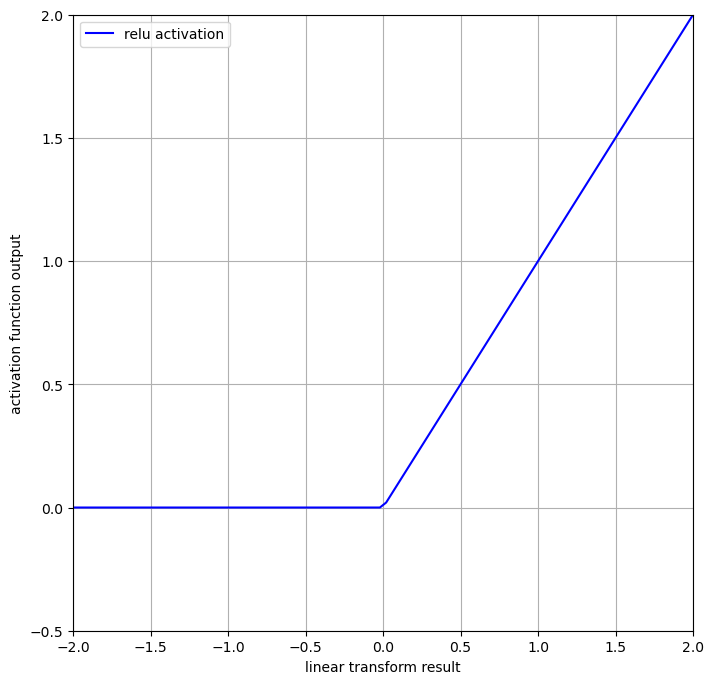

In [17]:
# relu is really the same as the max(output, 0), but we can use the tf.keras relu
from tensorflow.keras.activations import relu

linear_transform = np.linspace(-2.0, 2.0, 100)
plt.plot(linear_transform, relu(linear_transform), 'b-', label='relu activation')
plt.axis([-2, 2, -0.5, 2.0])
plt.legend()
plt.xlabel('linear transform result')
plt.ylabel('activation function output')
plt.grid();

The final layer uses a `sigmoid` activation function, which you should already be familiar with as well.
The sigmoid activation is a common activation for
simple binary classification.  It squashes the output into a value between 0 and 1, and can thus
be interpreted as a probability estimate of the binary output.  When we need to make an actual decision,
we usually use a threshold of 0.5 for the final prediction of a 0 or 1 binary label.

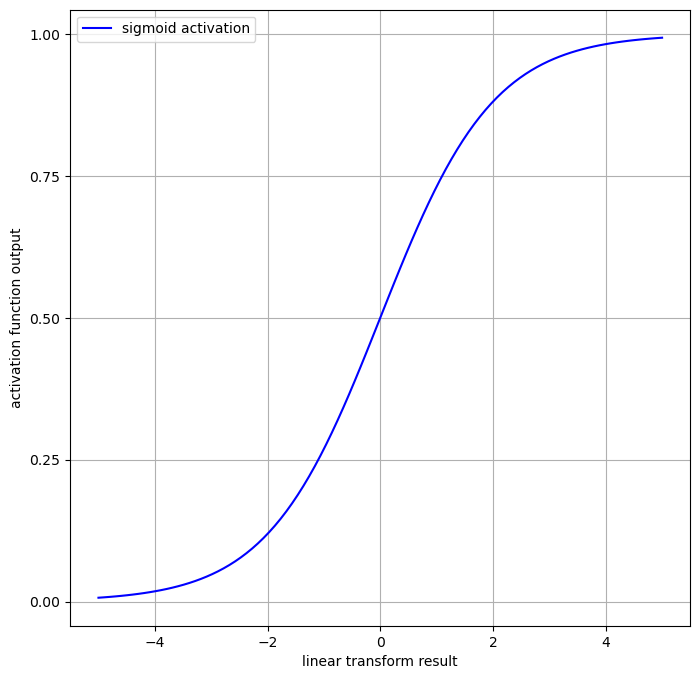

In [18]:
from tensorflow.keras.activations import sigmoid

linear_transform = np.linspace(-5.0, 5.0, 100)
plt.plot(linear_transform, sigmoid(linear_transform), 'b-', label='sigmoid activation')
plt.yticks([0, 0.25, 0.5, 0.75, 1.0])
plt.legend()
plt.xlabel('linear transform result')
plt.ylabel('activation function output')
plt.grid();

### What are activation functions and why are they necessary?

Without an activation function like `relu` or `sigmoid` (also called a non-linearity), the `Dense`
layer would consist of two linear operations, a dot product and addition

```
output = input @ W + b
```

The layer could only perform **linear transformations** (also called affine transformations) of the input
data.  The **hypothesis space** of such a layer would be the set of all possible linear transformations of the
input data into a 16-dimensional space (assuming we use 16 units in the layer).

Linear transformations are limited.  Also multiple layers would not help, a sequence of linear transformations
is no more powerful than 1 linear transformation.

In order to get access to much richer hypothesis space that will benefit from deep representations, you need
a non-linearity in the function transformation.  `relu` is simple, but is a very popular example of
a non-linear activation function.

Finally we need a loss function and an optimizer.  

Its best to use `binary_crossentropy` loss for binary classification problems.  *Crossentropy* is a quantity 
from the field of information theory that measures the distance between probability distributions, or in
this case, between the ground-truth distribution and your predictions.

As for optimizer, we will use `rmsprop`, which is usually a good default choice for virtually
any problem.

With those choices made, we can now "compile" our model architecture using the Keras API.  Recall that this step sets the optimizer, loss function and metrics,
and sets up the model layers internally for use by `TensorFlow` to perform automatic differentiation.

In [19]:
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

## 4.1.4 Validating your approach

You should not evalute deep learning models (or ML models in general) on the performnce on the training data.
The real question is how well models do on data it has not been trained with and has not seen before.

It is standard practice to use a validation set to monitor accuracy of a model during training.  This is
separate from a final test data set, which would be used to evaluate the final performance overall
after all training and comparision of different model architectures has occurred.

So we are not going to touch the test data set yet. Here we create a validation set by hand by setting asside
10,000 samples from the original training data of our IMDB review dataset.

Setting aside a validation set.

In [20]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

print(x_val.shape)
print(partial_x_train.shape)

(10000, 10000)
(15000, 10000)


We will now train for 20 epochs in mini-batches of 512 samples.  At the same time we monitor loss and
accuracy on the 10,000 validation set samples we set apart.  

Training your model.

In [21]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20


I0000 00:00:1748884819.220500   13724 service.cc:152] XLA service 0x730ac8003840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748884819.220646   13724 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
I0000 00:00:1748884819.417357   13724 cuda_dnn.cc:529] Loaded cuDNN version 90300


16/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6401 - loss: 0.6565

I0000 00:00:1748884821.048035   13724 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 149ms/step - accuracy: 0.6954 - loss: 0.6186 - val_accuracy: 0.8519 - val_loss: 0.4398
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8821 - loss: 0.3776 - val_accuracy: 0.8827 - val_loss: 0.3290
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9180 - loss: 0.2673 - val_accuracy: 0.8818 - val_loss: 0.3000
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9346 - loss: 0.2111 - val_accuracy: 0.8842 - val_loss: 0.2854
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9423 - loss: 0.1720 - val_accuracy: 0.8851 - val_loss: 0.2839
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9535 - loss: 0.1488 - val_accuracy: 0.8871 - val_loss: 0.2821
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9646 - loss: 0.1243 - val_accuracy: 0.8799 - val_loss: 0.3004
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9686 - loss: 0.1100 - val_accuracy: 0.8786 - val_loss: 0

Note that the call to `model.fit()` returns a `History` object.  This gives a history of the training
loss and validation metrics over the epochs of training.

In [22]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

This dictionary contains four entries, one per metric that was being monitored.  Each keys
value will be a list of the measurement of that metric during each epoch of training.

In [23]:
history_dict['loss']

[0.5543602705001831,
 0.35421299934387207,
 0.2605171799659729,
 0.2073030173778534,
 0.17529608309268951,
 0.15209682285785675,
 0.12820924818515778,
 0.11195654422044754,
 0.09739436209201813,
 0.08415291458368301,
 0.07543008774518967,
 0.06284543126821518,
 0.05588064715266228,
 0.04584384709596634,
 0.04359319433569908,
 0.03554631397128105,
 0.027162836864590645,
 0.02997250109910965,
 0.0231320783495903,
 0.017487678676843643]

A list of numbers of the loss is not so easy to interpret, so lets visualize the loss using a matplotlib figure.  Since we are going
to be visualizing the loss mulitple times in this notebook, and want to visualize separately for the training loss and the validation
loss, lets abstract the visualization into a function call.  While we are at it, we will abstract it so it can look at either
loss or accuracy metrics, and can be called to plot in a given axis so that we can create subplots and arrange figures as needed.

In [24]:
def plot_history(ax, history_dict, metric_key):
    """Plot the asked for metrics. Usually we need to plot the metric from the training
    data and its corresponding measurement using the validation data, thus we pass in
    two keys for the training and validation metric to plot.

    Arguments
    ---------
    ax - a matplotlib figure axis to create plot onto
    history_dict - A Python dictionary whose keys should return list like enumerable
      items holding the measured metrics over some number of epochs of training.
    metric_key - The string key for the metric, validation data is assumed to be
      accessible as "val_" + metric_key


    """
    # setup epochs and keys/labels for the plot
    train_key = metric_key
    train_label = "Training " + metric_key
    val_key = "val_" + metric_key
    val_label = "Validation " + metric_key
    epochs = np.arange(1, len(history_dict[train_key]) + 1)
    
    # create the plot of the train and test metric
    ax.plot(epochs, history_dict[train_key], 'r-', label=train_label)
    ax.plot(epochs, history_dict[val_key], 'b-', label=val_label)
    ax.set_xlabel('Epochs')
    ax.set_ylabel(metric_key)
    ax.set_xticks(epochs)
    ax.grid()
    ax.legend();

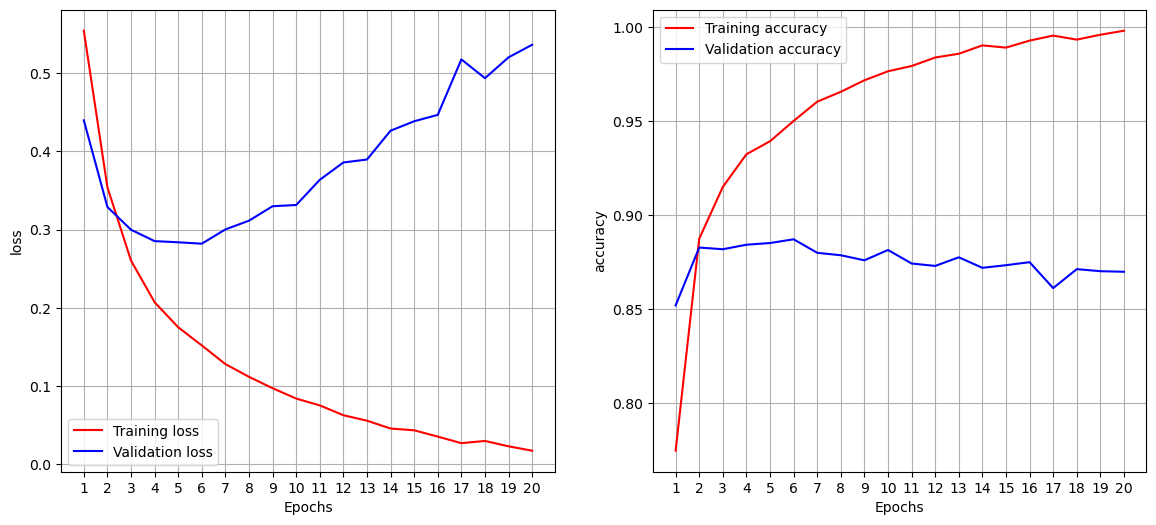

In [25]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history_dict, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history_dict, 'accuracy')

As you can see, training loss decreases with each epoch of training, and training accuracy improves.

However, validation loss gets worse and accuracy does not improve nor is it ever as good as training accuracy.

This model performs much better on the training data than on the validation data.  

This is an example of **overfitting**.  After the 4th epoch validation loss stops decreasing.  We are
overoptimizing on the training data and end up learning representations that are specific to
the training data (noise) and don't generalize.

We can use a range of techniques to mitigate overfitting.  The simplest approach is to stop training when
validation loss starts increasing, e.g. for only 4 epochs.

Let's train a new model from scratch for four epochs, then evaluate its performance on the test data.

In [26]:
model = keras.Sequential([
            layers.Dense(16, activation="relu"),
            layers.Dense(16, activation="relu"),
            layers.Dense(1, activation="sigmoid")
])

# train the model for 4 epochs
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.fit(x_train, y_train, epochs=4, batch_size=512)


# determine results on the test data, first number is the test loss
# and second is the accuracy
results = model.evaluate(x_test, y_test)
print(results)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.7580 - loss: 0.5335
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9061 - loss: 0.2755
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9251 - loss: 0.2086
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9409 - loss: 0.1727
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8791 - loss: 0.2951
[0.2950141727924347, 0.8812000155448914]


This naive approach achieves an accuracy of about 87%.  State-of-the-art approaches should be able to get close to 95% accuracy
on test data.

## 4.1.5 Using a trained model to generate predictions on new data

After training a model, you can use it to make predictions on any data, seen or not seen
before in the training. 

Can use `predict` method of trained model to generate predictions on new data.  These are the raw
output activitations, so represent the probability that the review is a positive review, e.g. numbers
closer to 1 are predicted to be positive reviews, and numbers closer to 0 are predicted to be negative
reviews.

In [27]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[0.158 ],
       [0.9993],
       [0.5157],
       ...,
       [0.0829],
       [0.0539],
       [0.5283]], dtype=float32)

## 4.1.6 Further experiments

Left as an exercise for students.  See if you can improve the model.

- Try more representation layers
- Try more or fewer units in layers
- Try using `mse` loss instead of `binary_crossentropy`
- Try using `tanh` activation instead of `relu`.

## 4.1.7 Wrapping up

<font color='blue'>
    
What you should remember from this example:

- Usually need to do quite a bit of preprocessing.
- Stacks of `Dense` layers with `relu` activations can solve a wide range of problems.
- In binary classification, model should end with a `Dense` layer with one unit using `sigmoid` activation.
- Should usually use `binary_crossentropy` loss function for scalar sigmoid output on binary classification problems.
- The `rmsprop` optimizer is generally good enough for most nn/deep learning problems.
- Neural networks eventually start overfitting and get increasingly worse at generalizing to unseen data.  Need to always
  fight overfitting and monitor performance.